## Importing libaries and data 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import os

In [2]:
#creating path for data import 
path = r'/Users/thomaskimber/Desktop/Task 7'

In [3]:
# importing UFC data csv 
df = pd.read_csv(os.path.join(path, 'ufc_data.csv' ), index_col = False)

In [4]:
df.shape

(6012, 144)

In [5]:
df.dtypes

R_fighter        object
B_fighter        object
Referee          object
date             object
location         object
                 ...   
R_Height_cms    float64
R_Reach_cms     float64
R_Weight_lbs    float64
B_age           float64
R_age           float64
Length: 144, dtype: object

In [7]:
# Check for missing values

df.isnull().sum() 

R_fighter         0
B_fighter         0
Referee          32
date              0
location          0
               ... 
R_Height_cms      4
R_Reach_cms     406
R_Weight_lbs      2
B_age           172
R_age            63
Length: 144, dtype: int64

Creating Corr table to turn into a heat map

In [10]:
df.corr(numeric_only=True)

,title_bout,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_TD_pct,B_avg_opp_TD_pct,B_avg_SUB_ATT,B_avg_opp_SUB_ATT,B_avg_REV,...,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
title_bout,1.000000,0.099967,-0.056049,0.083308,-0.095428,0.061260,-0.085671,-0.012854,-0.032963,-0.022165,...,0.008981,0.110314,0.154448,0.058763,0.050199,0.004768,0.019804,0.033047,0.035363,0.006207
B_avg_KD,0.099967,1.000000,-0.104747,0.136838,-0.156778,-0.106704,-0.164900,-0.134718,-0.105846,-0.088655,...,0.039571,0.107846,0.137351,0.045532,0.025329,0.078261,0.098795,0.085813,-0.004818,0.056912
B_avg_opp_KD,-0.056049,-0.104747,1.000000,-0.130582,0.190190,-0.090898,-0.048148,-0.081683,-0.058100,-0.043111,...,-0.012352,-0.049124,0.014856,-0.025439,-0.032146,0.096080,0.079884,0.084959,0.123926,0.010644
B_avg_SIG_STR_pct,0.083308,0.136838,-0.130582,1.000000,-0.037459,0.155618,-0.089951,0.054535,-0.004450,0.025292,...,0.003556,0.051352,0.090761,0.038491,0.044963,0.082542,0.088039,0.127083,0.019134,0.054562
B_avg_opp_SIG_STR_pct,-0.095428,-0.156778,0.190190,-0.037459,1.000000,-0.115699,0.206691,0.005433,0.094865,0.050435,...,-0.074464,-0.118591,-0.063557,-0.038938,-0.047943,0.062280,0.052204,0.068383,0.060397,0.004371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R_Height_cms,0.004768,0.078261,0.096080,0.082542,0.062280,-0.078851,-0.052438,-0.065327,-0.082623,-0.076577,...,-0.120690,-0.097630,0.222057,0.060497,0.029378,1.000000,0.893139,0.791020,0.151470,0.075446
R_Reach_cms,0.019804,0.098795,0.079884,0.088039,0.052204,-0.077097,-0.055362,-0.073663,-0.069763,-0.079387,...,-0.110271,-0.066384,0.246020,0.080217,0.070958,0.893139,1.000000,0.770771,0.157938,0.080481
R_Weight_lbs,0.033047,0.085813,0.084959,0.127083,0.068383,-0.066974,-0.071878,-0.095280,-0.101754,-0.098811,...,-0.120738,-0.123500,0.242215,-0.002397,0.047829,0.791020,0.770771,1.000000,0.200576,0.178268
B_age,0.035363,-0.004818,0.123926,0.019134,0.060397,-0.095572,-0.042217,-0.135589,-0.084060,-0.097093,...,0.079948,0.137939,0.239222,0.093656,0.070484,0.151470,0.157938,0.200576,1.000000,0.190991


In [19]:
#heatmap of fighter stats for corr analysis 

In [16]:
# Encode Winner: 1 = Red wins, 0 = Blue wins, NaN = Draw/Other
df["Winner_encoded"] = df["Winner"].apply(
    lambda x: 1 if x == "Red" else (0 if x == "Blue" else None)
)

# Select meaningful numeric variables for EDA
eda_columns = [
    "R_age", "R_Height_cms", "R_Reach_cms", "R_weight_lbs", "R_KD",
    "R_SIG_STR_pct", "R_TD_pct", "R_SUB_ATT", "R_PASS", "R_REV",
    "R_wins", "R_losses", "R_total_rounds_fought", "R_total_time_fought(seconds)",

    "B_age", "B_Height_cms", "B_Reach_cms", "B_weight_lbs", "B_KD",
    "B_SIG_STR_pct", "B_TD_pct", "B_SUB_ATT", "B_PASS", "B_REV",
    "B_wins", "B_losses", "B_total_rounds_fought", "B_total_time_fought(seconds)",

    "Winner_encoded"
]

eda_df = df[[col for col in eda_columns if col in df.columns]]

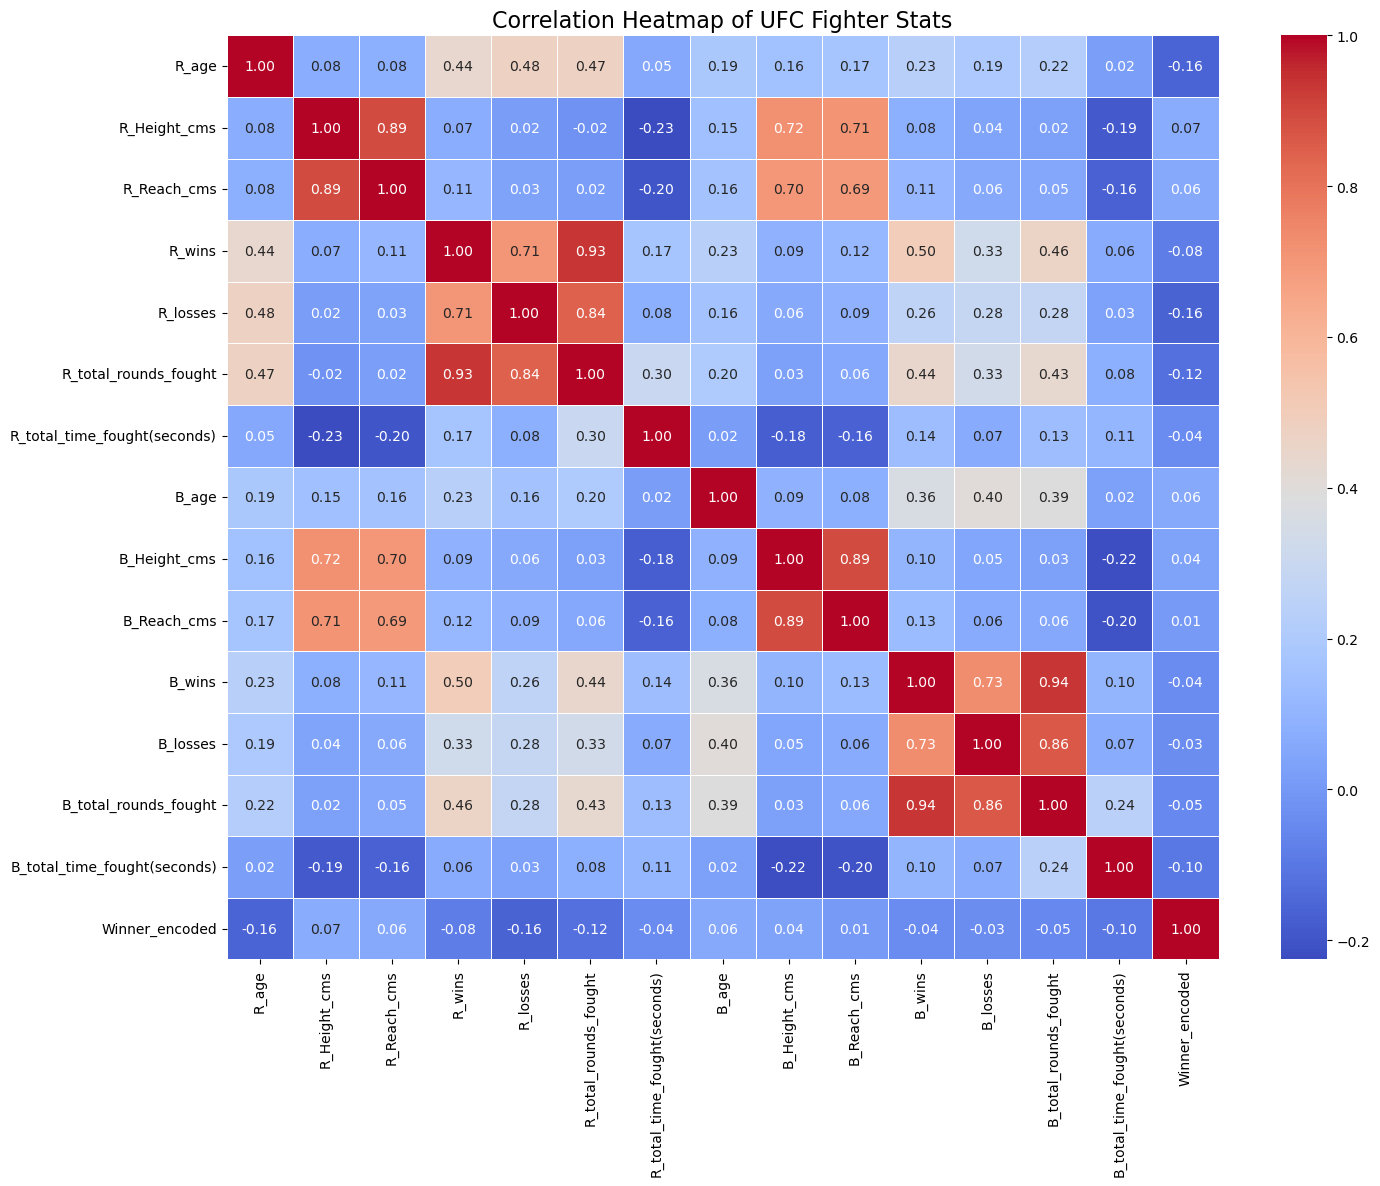

In [18]:
corr = eda_df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,       # show numbers
    fmt=".2f",        # 2 decimal places
    linewidths=0.5,
    cbar=True
)
plt.title("Correlation Heatmap of UFC Fighter Stats", fontsize=16)
plt.show()


The heat map above presents a substantial amount of statistics from the fighters, and I intentionally did so to identify any notable patterns or trends. From the heat map, the correlation between age, losses, and total time fought appears to be quite intriguing. Further analysis could be insightful in examining the relationship between age, the number of fights, and the length of fights to determine whether experience directly correlates with the anticipated duration of a fight and if the older or longer fights go are they more likely to lose future fights. 

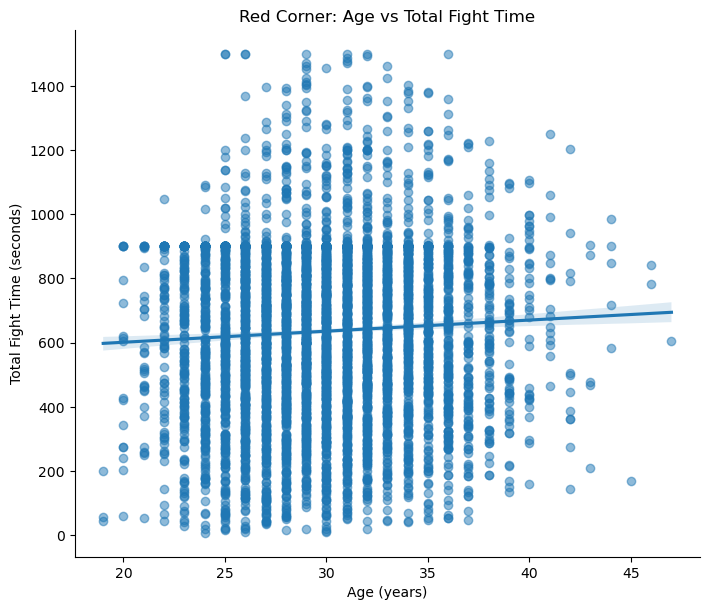

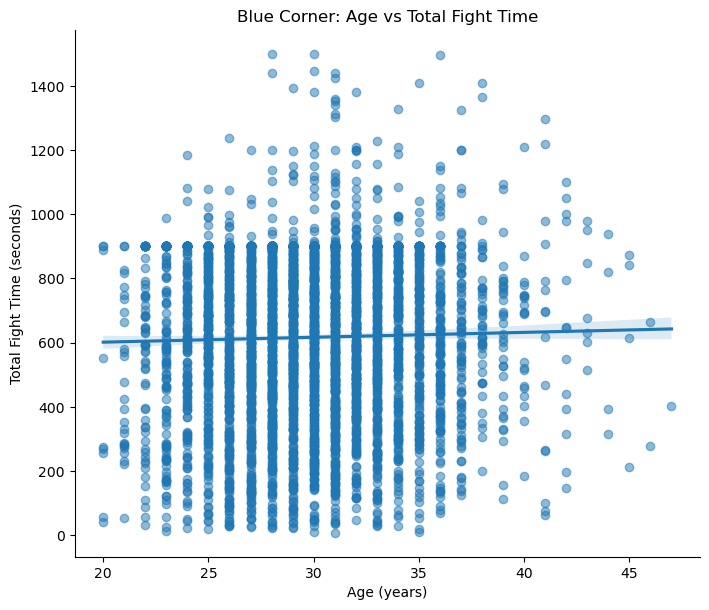

In [25]:
# Scatter plot for Red corner: Age vs Total Fight Time
sns.lmplot(
    x="R_age",
    y="R_total_time_fought(seconds)",
    data=df,
    height=6,
    aspect=1.2,
    scatter_kws={'alpha':0.5}
)
plt.title("Red Corner: Age vs Total Fight Time")
plt.xlabel("Age (years)")
plt.ylabel("Total Fight Time (seconds)")
plt.show()

# Scatter plot for Blue corner: Age vs Total Fight Time
sns.lmplot(
    x="B_age",
    y="B_total_time_fought(seconds)",
    data=df,
    height=6,
    aspect=1.2,
    scatter_kws={'alpha':0.5}
)
plt.title("Blue Corner: Age vs Total Fight Time")
plt.xlabel("Age (years)")
plt.ylabel("Total Fight Time (seconds)")
plt.show()

There is little to no correlation between age and length of fight. 

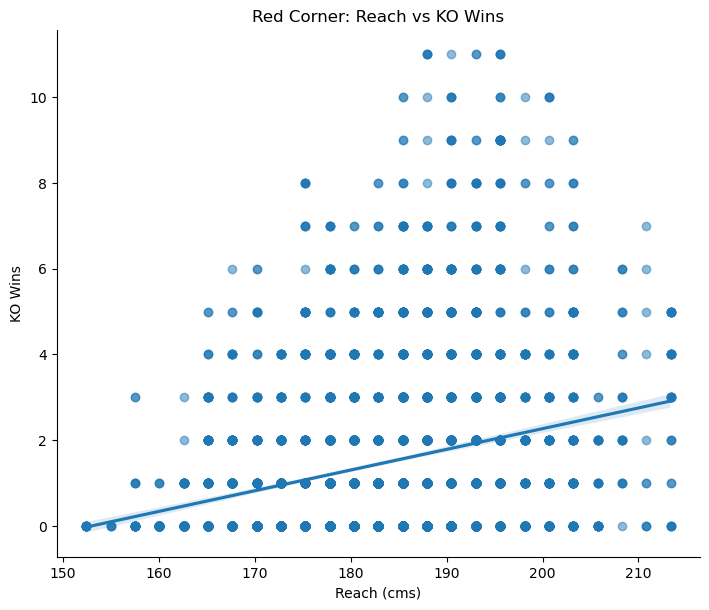

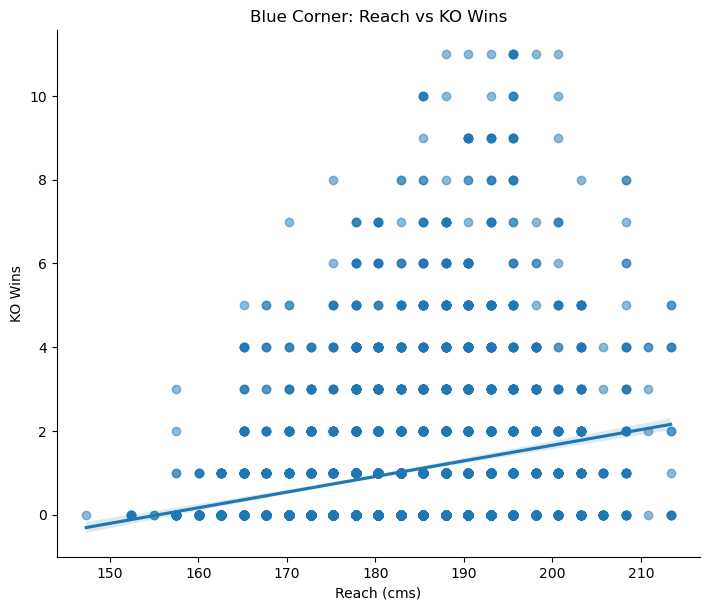

In [24]:
# Red corner: Reach vs KO wins
sns.lmplot(x="Red_Reach", y="Red_KO", data=eda_df, height=6, aspect=1.2, scatter_kws={'alpha':0.5})
plt.title("Red Corner: Reach vs KO Wins")
plt.xlabel("Reach (cms)")
plt.ylabel("KO Wins")
plt.show()

# Blue corner: Reach vs KO wins
sns.lmplot(x="Blue_Reach", y="Blue_KO", data=eda_df, height=6, aspect=1.2, scatter_kws={'alpha':0.5})
plt.title("Blue Corner: Reach vs KO Wins")
plt.xlabel("Reach (cms)")
plt.ylabel("KO Wins")
plt.show()

I decied then to look at the reach of the fighter and the KO wins and there is a small correlation between reach going up for fighters and Ko wins 

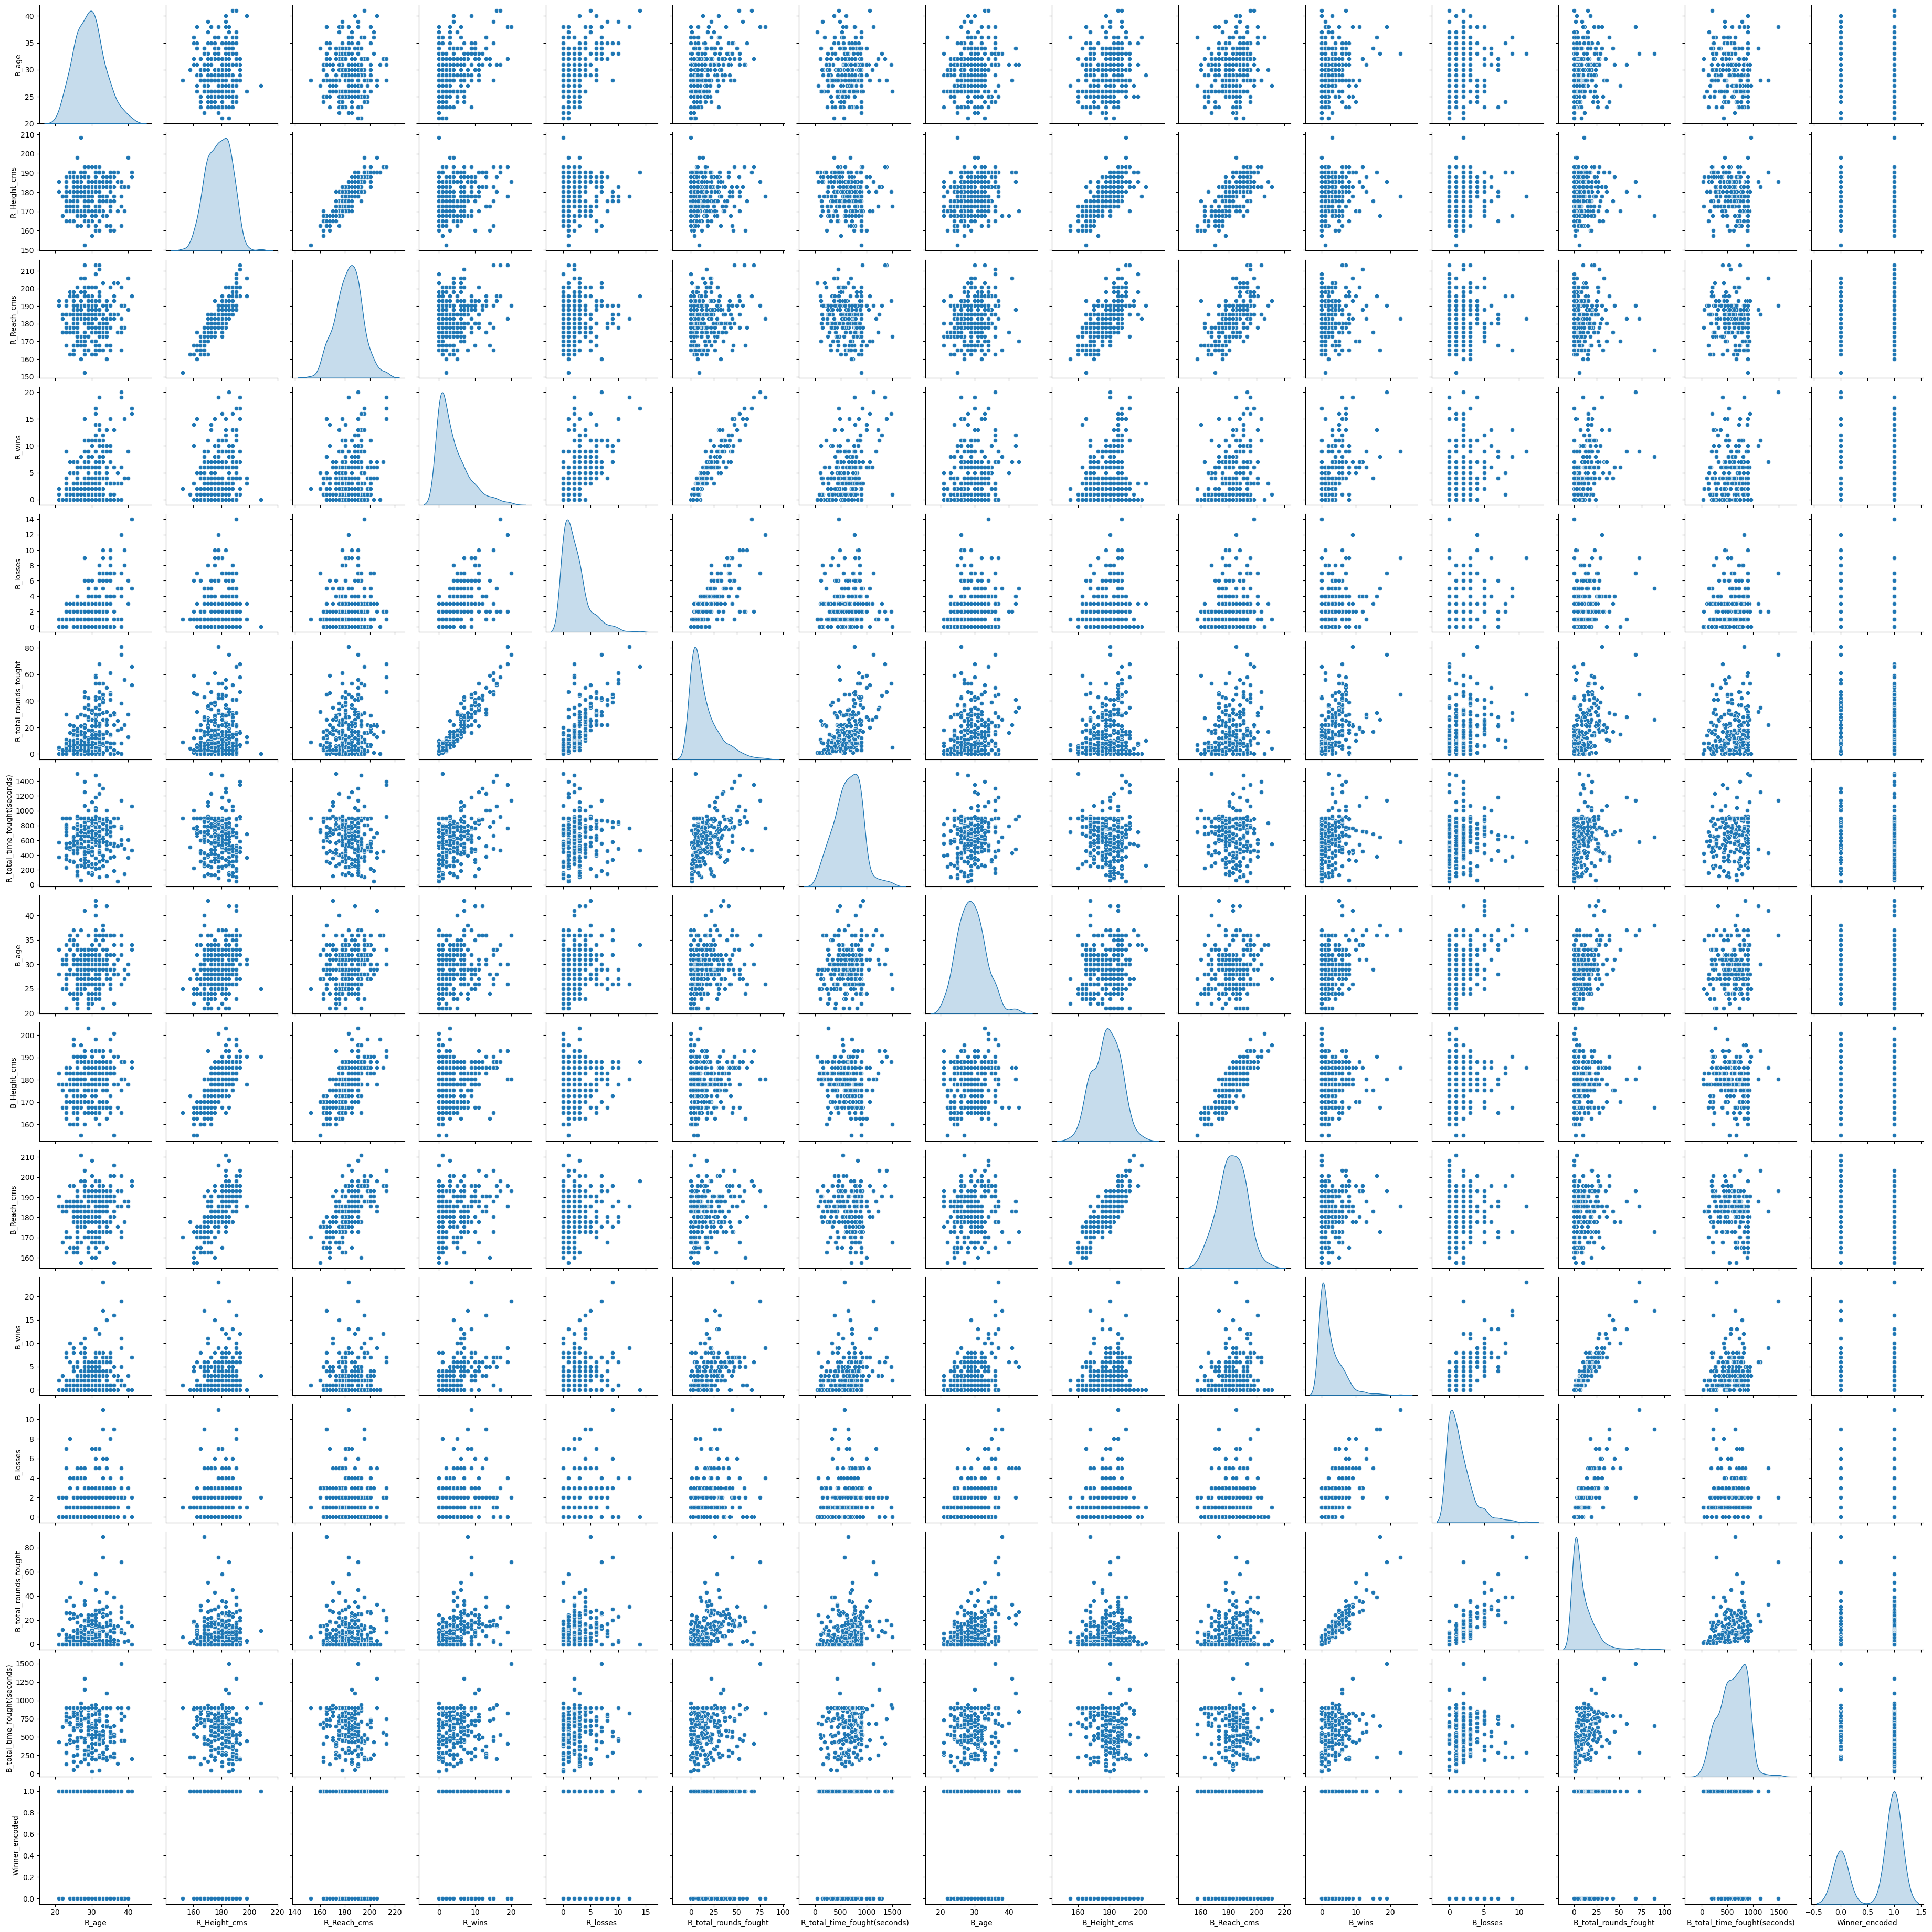

In [21]:
sns.pairplot(eda_df.sample(300), diag_kind="kde")  # sample for speed
plt.show()

lots here but looking at the data there semms to be interesting looking into total rounds faught and wins 

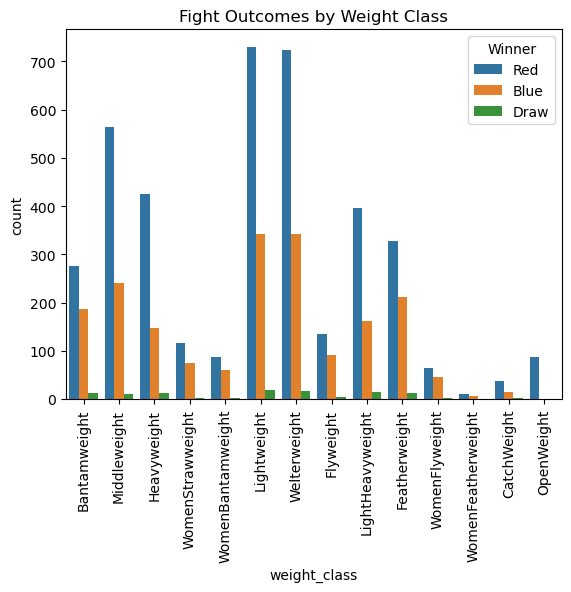

In [26]:
sns.countplot(data=df, x="weight_class", hue="Winner")
plt.xticks(rotation=90)
plt.title("Fight Outcomes by Weight Class")
plt.show()

Lightweight and Welterweight are by far the most popular weight classes. also it seems to be tht red wins way more than blue, it would be worth looking at if the colour represnt the ranking of the fighters 

Based on earlier questions, we can now answer:
Does age affect the length of the fight? NO
Does reach help KO's? There is a small correlation between the incrase in reach and KO's 


New questions from EDA:
Is Red corner placement giving a measurable advantage?
Are certain weight classes more predictable?
Do fighters with long fight time (grinders) win more often than KO artists?

Hypotheses to test later:
H1: Younger fighters are more likely to win than older fighters.
H2: Reach length is positively associated with winning.
H3: Higher striking accuracy strongly predicts winning.
H4: More UFC experience (wins, rounds fought) increases probability of winning.